# exp008 - FakeAVCeleb zero-shot cross-dataset evaluation

take the already-trained AV-Deepfake1M++ visual/audio/fusion setup and test it on FakeAVCeleb **without fitting anything to FakeAVCeleb labels**.

three views are kept:

1. full natural distribution - all 21,544 unique videos
2. source-matched four-condition view - one example per source for each condition
3. source-matched binary view - one real + one deterministic fake example per source

FakeAVCeleb does not give temporal manipulation intervals compatible with the source dataset, so this experiment is video-level transfer rather than cross-dataset temporal IoU.

## run / data reminder

this depends on the audited FakeAVCeleb manifest plus the completed exp004, exp005 and exp007 source runs.

the smoke setup uses 20 shared source identities first. the completed full run uses `MAX_SOURCES = None`.

important zero-shot rule: no FakeAVCeleb labels are used to fit source models, choose thresholds, choose pooling, or fit the learned fusion.

In [1]:
# imports + reproducibility
from pathlib import Path
from datetime import datetime
import json
import shutil
import zipfile
import hashlib
import random
import gc
import subprocess
import math

import numpy as np
import pandas as pd
import cv2
cv2.setNumThreads(0)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, FileLink

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_float32_matmul_precision("high")

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
# longer helpers are split by purpose for the external evaluation
from utils.data_utils import (
    find_run,
    result_dir,
    build_source_matched_four,
    build_source_matched_binary,
    parse_bool_series,
    manifest_fingerprint,
)

from utils.scoring_utils import (
    TemporalLinearHead,
    ConvNeXtFrameFeatureExtractor,
    extract_visual_scores,
    probe_audio,
    decode_audio,
    extract_audio_scores,
)

from utils.eval_utils import (
    load_source_score,
    calculate_metrics,
    tune_threshold,
    cluster_bootstrap_metrics,
)


Torch: 2.3.1+cu121
CUDA: True
GPU: NVIDIA A40


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# main exp008 settings
PROJECT_ROOT = Path("/home/jovyan/MSC_PROJECT")
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
DATA_ROOT = PROJECT_ROOT / "data" / "FakeAVCeleb_v1.2"
AUDIT_MANIFEST = DATA_ROOT / "metadata_audit" / "fakeavceleb_manifest_unique.csv"
EXPORTS_DIR = PROJECT_ROOT / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_FILENAME = "exp008_fakeavceleb_crossdataset.ipynb"
NOTEBOOK_PATH = PROJECT_ROOT / NOTEBOOK_FILENAME
BASE_RUN_NAME = "exp008_fakeavceleb_crossdataset"
PIPELINE_VERSION = "metadata_audited_v2"

VISUAL_SOURCE_CANDIDATES = [
    "exp004_visual_temporal_bal40k",
    "004_visual_temporal_bal40k",
]
AUDIO_SOURCE_CANDIDATES = [
    "exp005_audio_temporal_bal40k",
    "005_audio_temporal_bal40k",
]
FUSION_SOURCE_CANDIDATES = [
    "exp007_late_fusion_bal40k",
    "007_late_fusion_bal40k",
]

NUM_VISUAL_FRAMES = 64
IMAGE_SIZE = 224
NUM_AUDIO_WINDOWS = 64
AUDIO_SAMPLE_RATE = 16_000
AUDIO_WINDOW_SECONDS = 0.96
N_FFT = 400
HOP_LENGTH = 160
WIN_LENGTH = 400
AUDIO_FEATURE_DIM = 2 * (N_FFT // 2 + 1)

VISUAL_BATCH_SIZE = 8
AUDIO_BATCH_SIZE = 16
NUM_WORKERS = 2
PREFETCH_FACTOR = 1
PIN_MEMORY = False
CHUNK_SIZE = 256

# smoke run used 20; the completed full evaluation uses None
MAX_SOURCES = None

# bootstrap resamples source identities rather than individual videos
BOOTSTRAP_REPS = 1_000

RUN_NAME = (
    BASE_RUN_NAME
    if MAX_SOURCES is None
    else f"{BASE_RUN_NAME}_smoke{MAX_SOURCES}src"
)

EXPECTED_UNIQUE_COUNTS = {
    "RealVideo-RealAudio": 500,
    "RealVideo-FakeAudio": 500,
    "FakeVideo-RealAudio": 9_709,
    "FakeVideo-FakeAudio": 10_835,
}

TYPE_TO_CONDITION = {
    "RealVideo-RealAudio": "real",
    "RealVideo-FakeAudio": "real_video_fake_audio",
    "FakeVideo-RealAudio": "fake_video_real_audio",
    "FakeVideo-FakeAudio": "fake_video_fake_audio",
}

CONFIG = {
    "run_name": RUN_NAME,
    "pipeline_version": PIPELINE_VERSION,
    "external_dataset": "FakeAVCeleb_v1.2",
    "evaluation": "zero-shot cross-dataset; no external retraining or threshold tuning",
    "audited_manifest": str(AUDIT_MANIFEST),
    "num_visual_frames": NUM_VISUAL_FRAMES,
    "num_audio_windows": NUM_AUDIO_WINDOWS,
    "max_sources": MAX_SOURCES,
    "bootstrap_reps": BOOTSTRAP_REPS,
    "seed": SEED,
}
CONFIG

{'run_name': 'exp008_fakeavceleb_crossdataset',
 'pipeline_version': 'metadata_audited_v2',
 'external_dataset': 'FakeAVCeleb_v1.2',
 'evaluation': 'zero-shot cross-dataset; no external retraining or threshold tuning',
 'audited_manifest': '/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2/metadata_audit/fakeavceleb_manifest_unique.csv',
 'num_visual_frames': 64,
 'num_audio_windows': 64,
 'max_sources': None,
 'bootstrap_reps': 1000,
 'seed': 42}

In [3]:
# create the run folders and locate the completed source experiments/checkpoints

RUN_DIR = EXPERIMENTS_DIR / RUN_NAME
DIRS = {
    name: RUN_DIR / name
    for name in ["manifests", "results", "plots", "notebook", "score_shards"]
}
for path in [RUN_DIR, *DIRS.values()]:
    path.mkdir(parents=True, exist_ok=True)

(RUN_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2))

VISUAL_SOURCE_NAME, VISUAL_RUN = find_run(VISUAL_SOURCE_CANDIDATES, EXPERIMENTS_DIR)
AUDIO_SOURCE_NAME, AUDIO_RUN = find_run(AUDIO_SOURCE_CANDIDATES, EXPERIMENTS_DIR)
FUSION_SOURCE_NAME, FUSION_RUN = find_run(FUSION_SOURCE_CANDIDATES, EXPERIMENTS_DIR)

VISUAL_CKPT = VISUAL_RUN / "checkpoints" / "best_temporal_head.pt"
AUDIO_CKPT = AUDIO_RUN / "checkpoints" / "best_audio_temporal_head.pt"
FUSION_RESULTS = result_dir(FUSION_RUN)

for path in [VISUAL_CKPT, AUDIO_CKPT]:
    if not path.exists():
        raise FileNotFoundError(path)

print("Visual source:", VISUAL_RUN)
print("Audio source:", AUDIO_RUN)
print("Fusion source:", FUSION_RUN)

Visual source: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k
Audio source: /home/jovyan/MSC_PROJECT/experiments/exp005_audio_temporal_bal40k
Fusion source: /home/jovyan/MSC_PROJECT/experiments/exp007_late_fusion_bal40k


In [4]:
# columns required from the audited FakeAVCeleb manifest
REQUIRED_AUDIT_COLUMNS = {
    "source", "target1", "target2", "method", "category", "type",
    "race", "gender", "filename", "relative_path", "absolute_path",
    "file_exists", "category_type_valid", "type_in_path",
    "source_matches_directory", "is_mp4", "visual_fake", "audio_fake",
    "binary_label", "methods_all", "method_count", "method_ambiguous",
}

# re-check the audited manifest before using it as the external source of truth

if not AUDIT_MANIFEST.is_file():
    raise FileNotFoundError(
        f"Audited manifest not found: {AUDIT_MANIFEST}\n"
        "Run fakeavceleb_metadata_audit.py before this notebook."
    )

full_manifest = pd.read_csv(AUDIT_MANIFEST)
missing_columns = REQUIRED_AUDIT_COLUMNS - set(full_manifest.columns)
if missing_columns:
    raise ValueError(f"Audited manifest is missing columns: {sorted(missing_columns)}")

# Revalidate the key audit guarantees inside the evaluation notebook.
if full_manifest["relative_path"].duplicated().any():
    raise ValueError("Audited manifest still contains duplicate physical paths.")


def parse_bool_series(series, column_name):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalised = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "false": False,
        "0": False,
        "no": False,
    }
    unknown = sorted(set(normalised) - set(mapping))
    if unknown:
        raise ValueError(
            f"Could not parse boolean column {column_name}; unknown values: {unknown}"
        )
    return normalised.map(mapping).astype(bool)


boolean_checks = [
    "file_exists",
    "category_type_valid",
    "type_in_path",
    "source_matches_directory",
    "is_mp4",
]
for column in boolean_checks:
    full_manifest[column] = parse_bool_series(full_manifest[column], column)
    if not full_manifest[column].all():
        raise ValueError(f"Audit guarantee failed for column: {column}")

full_manifest["method_ambiguous"] = parse_bool_series(
    full_manifest["method_ambiguous"],
    "method_ambiguous",
)

full_manifest["path"] = full_manifest["absolute_path"].astype(str)
missing_files = [path for path in full_manifest["path"] if not Path(path).is_file()]
if missing_files:
    raise FileNotFoundError(
        f"{len(missing_files)} audited files are no longer present. First: {missing_files[0]}"
    )

full_manifest["condition"] = full_manifest["type"].map(TYPE_TO_CONDITION)
if full_manifest["condition"].isna().any():
    unknown_types = sorted(full_manifest.loc[full_manifest["condition"].isna(), "type"].unique())
    raise ValueError(f"Unknown FakeAVCeleb types: {unknown_types}")

for column in ["visual_fake", "audio_fake", "binary_label"]:
    full_manifest[column] = full_manifest[column].astype(int)

actual_counts = full_manifest["type"].value_counts().to_dict()
if actual_counts != EXPECTED_UNIQUE_COUNTS:
    raise ValueError(
        f"Unexpected unique video counts. Actual={actual_counts}; expected={EXPECTED_UNIQUE_COUNTS}"
    )

if len(full_manifest) != 21_544:
    raise ValueError(f"Expected 21,544 unique videos, found {len(full_manifest):,}")

if int(full_manifest["method_ambiguous"].sum()) != 22:
    raise ValueError("Expected exactly 22 paths with ambiguous method metadata.")

# The smoke test uses the same identities across all four conditions.
source_matched_all, shared_sources_all = build_source_matched_four(full_manifest, seed=SEED)
if MAX_SOURCES is None:
    manifest = full_manifest.copy()
else:
    manifest, smoke_sources = build_source_matched_four(
        full_manifest,
        seed=SEED,
        max_sources=MAX_SOURCES,
    )

manifest = manifest.sort_values(["condition", "source", "relative_path"]).reset_index(drop=True)
manifest["external_index"] = np.arange(len(manifest), dtype=int)

manifest_hash = manifest_fingerprint(manifest, PIPELINE_VERSION)


manifest.to_csv(DIRS["manifests"] / "fakeavceleb_evaluation_manifest.csv", index=False)
full_manifest.to_csv(DIRS["manifests"] / "fakeavceleb_audited_full_manifest.csv", index=False)

print("Pipeline version:", PIPELINE_VERSION)
print("Manifest fingerprint:", manifest_hash)
print("Evaluation rows:", len(manifest))
print("Shared source identities across all four conditions:", len(shared_sources_all))
print("Ambiguous method paths retained once:", int(full_manifest["method_ambiguous"].sum()))
print("\nEvaluation condition counts:")
print(manifest["condition"].value_counts().sort_index())
display(manifest.head())

Pipeline version: metadata_audited_v2
Manifest fingerprint: f84eb0a2b6f3
Evaluation rows: 21544
Shared source identities across all four conditions: 499
Ambiguous method paths retained once: 22

Evaluation condition counts:
condition
fake_video_fake_audio    10835
fake_video_real_audio     9709
real                       500
real_video_fake_audio      500
Name: count, dtype: int64


,metadata_row,source,target1,target2,method,category,type,race,gender,filename,...,source_matches_directory,is_mp4,visual_fake,audio_fake,binary_label,methods_all,method_count,method_ambiguous,condition,external_index
0,17925,id00018,id00029,-,wav2lip,D,FakeVideo-FakeAudio,Caucasian (American),men,00181_id00029_wavtolip.mp4,...,True,True,1,1,1,wav2lip,1,False,fake_video_fake_audio,0
1,17926,id00018,id00052,-,wav2lip,D,FakeVideo-FakeAudio,Caucasian (American),men,00181_id00052_wavtolip.mp4,...,True,True,1,1,1,wav2lip,1,False,fake_video_fake_audio,1
2,9022,id00018,id00088,id01096,fsgan-wav2lip,D,FakeVideo-FakeAudio,Caucasian (American),men,00181_id00088_6WIDWxr8vuU_id01096_wavtolip.mp4,...,True,True,1,1,1,fsgan-wav2lip,1,False,fake_video_fake_audio,2
3,9023,id00018,id00169,V1xAwwG29U,fsgan-wav2lip,D,FakeVideo-FakeAudio,Caucasian (American),men,00181_id00169__V1xAwwG29U_id01210_wavtolip.mp4,...,True,True,1,1,1,fsgan-wav2lip,1,False,fake_video_fake_audio,3
4,9024,id00018,id00243,id00945,fsgan-wav2lip,D,FakeVideo-FakeAudio,Caucasian (American),men,00181_id00243_oWwEIXM3oZQ_id00945_wavtolip.mp4,...,True,True,1,1,1,fsgan-wav2lip,1,False,fake_video_fake_audio,4


In [5]:
# rebuild the controlled four-condition and binary views from the active manifest

# Rebuild controlled views from the active evaluation manifest.
source_matched4, shared_sources = build_source_matched_four(manifest, seed=SEED)
source_matched_binary = build_source_matched_binary(source_matched4, seed=SEED)

if source_matched_binary["binary_label"].value_counts().to_dict() != {
    0: len(shared_sources),
    1: len(shared_sources),
}:
    raise RuntimeError("Source-matched binary view is not class-balanced.")

view_membership = pd.concat(
    [
        pd.DataFrame({
            "external_index": manifest["external_index"],
            "view": "full_natural" if MAX_SOURCES is None else "smoke_source_matched4",
        }),
        pd.DataFrame({
            "external_index": source_matched4["external_index"],
            "view": "source_matched4",
        }),
        pd.DataFrame({
            "external_index": source_matched_binary["external_index"],
            "view": "source_matched_binary",
        }),
    ],
    ignore_index=True,
)
view_membership.to_csv(DIRS["manifests"] / "evaluation_view_membership.csv", index=False)
source_matched4.to_csv(DIRS["manifests"] / "fakeavceleb_source_matched4.csv", index=False)
source_matched_binary.to_csv(
    DIRS["manifests"] / "fakeavceleb_source_matched_binary.csv",
    index=False,
)

view_summary = pd.concat(
    [
        manifest.assign(view="full_natural" if MAX_SOURCES is None else "smoke_source_matched4"),
        source_matched4.assign(view="source_matched4"),
        source_matched_binary.assign(view="source_matched_binary"),
    ],
    ignore_index=True,
).groupby(["view", "condition"]).agg(
    rows=("external_index", "size"),
    unique_sources=("source", "nunique"),
).reset_index()

view_summary.to_csv(DIRS["results"] / "evaluation_view_summary.csv", index=False)
display(view_summary)

print("Source-matched binary fake-condition counts:")
print(
    source_matched_binary[source_matched_binary["binary_label"] == 1]["condition"]
    .value_counts()
    .sort_index()
)

,view,condition,rows,unique_sources
0,full_natural,fake_video_fake_audio,10835,499
1,full_natural,fake_video_real_audio,9709,500
2,full_natural,real,500,500
3,full_natural,real_video_fake_audio,500,500
4,source_matched4,fake_video_fake_audio,499,499
5,source_matched4,fake_video_real_audio,499,499
6,source_matched4,real,499,499
7,source_matched4,real_video_fake_audio,499,499
8,source_matched_binary,fake_video_fake_audio,145,145
9,source_matched_binary,fake_video_real_audio,202,202


Source-matched binary fake-condition counts:
condition
fake_video_fake_audio    145
fake_video_real_audio    202
real_video_fake_audio    152
Name: count, dtype: int64


## load the source models

the visual and audio temporal heads are rebuilt only so their saved checkpoints can be loaded. nothing is retrained on FakeAVCeleb.

visual side keeps 64 ConvNeXt frame features. audio side uses the same 64 x 402 log-STFT features as exp005.

In [6]:
# rebuild the source architectures and load the saved temporal checkpoints

device = "cuda" if torch.cuda.is_available() else "cpu"

visual_encoder = ConvNeXtFrameFeatureExtractor().to(device).eval()
visual_ckpt = torch.load(VISUAL_CKPT, map_location=device)
visual_head = TemporalLinearHead(
    int(visual_ckpt.get("input_dim", 1024))
).to(device).eval()
visual_head.load_state_dict(visual_ckpt["model_state_dict"])

audio_ckpt = torch.load(AUDIO_CKPT, map_location=device)
audio_head = TemporalLinearHead(
    int(audio_ckpt.get("input_dim", AUDIO_FEATURE_DIM))
).to(device).eval()
audio_head.load_state_dict(audio_ckpt["model_state_dict"])

print("Device:", device)
print("Visual checkpoint epoch:", visual_ckpt.get("epoch"))
print("Audio checkpoint epoch:", audio_ckpt.get("epoch"))

Device: cuda
Visual checkpoint epoch: 19
Audio checkpoint epoch: 21


## temporal pooling + resumable scoring

each modality produces 64 probabilities per video. those are reduced to max, mean and top-5/10/20% means, matching the pooling used in the source fusion experiment.

external score extraction is chunked so an interrupted run can reuse a csv shard only when its `external_index` coverage exactly matches the current manifest chunk.

In [8]:
# run/reuse zero-shot visual scoring over the active FakeAVCeleb manifest

visual_scores = extract_visual_scores(
    manifest,
    visual_encoder=visual_encoder,
    visual_head=visual_head,
    device=device,
    score_shards_dir=DIRS["score_shards"],
    results_dir=DIRS["results"],
    manifest_hash=manifest_hash,
    num_visual_frames=NUM_VISUAL_FRAMES,
    image_size=IMAGE_SIZE,
    visual_batch_size=VISUAL_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
    pin_memory=PIN_MEMORY,
    chunk_size=CHUNK_SIZE,
)
print("Visual decode coverage:", visual_scores["visual_decode_ok"].mean())
display(visual_scores.head())

Visual decode coverage: 1.0


,external_index,visual_decode_ok,visual_frame_count,visual_positive_rate_05,visual_max,visual_mean,visual_top5_mean,visual_top10_mean,visual_top20_mean
0,0,1,120,0.437500,0.679497,0.479009,0.668798,0.657284,0.625169
1,1,1,120,0.359375,0.654257,0.457964,0.632803,0.620004,0.589342
2,2,1,120,0.500000,0.673287,0.479320,0.659886,0.642546,0.619873
3,3,1,81,0.468750,0.755488,0.498607,0.723745,0.710820,0.689579
4,4,1,117,0.125000,0.712183,0.402137,0.660550,0.621572,0.564689


In [9]:
# locate ffmpeg/ffprobe before checking FakeAVCeleb audio decoding
FFMPEG = shutil.which("ffmpeg")
FFPROBE = shutil.which("ffprobe")
if not FFMPEG or not FFPROBE:
    raise RuntimeError("ffmpeg and ffprobe are required.")



# preflight a few source-matched examples from every condition before the full audio run
# Preflight uses source-matched examples from every condition.
preflight_sample = (
    source_matched4.sort_values(["condition", "source"])
    .groupby("condition", group_keys=False)
    .head(3)
)
preflight_rows = []
for _, row in preflight_sample.iterrows():
    waveform, decode_ok, error, codec_name = decode_audio(
        row.path,
        ffmpeg_bin=FFMPEG,
        ffprobe_bin=FFPROBE,
        audio_sample_rate=AUDIO_SAMPLE_RATE,
    )
    preflight_rows.append(
        {
            "path": row.path,
            "condition": row.condition,
            "source": row.source,
            "decode_ok": int(decode_ok),
            "codec_name": codec_name,
            "samples": len(waveform),
            "duration_sec": len(waveform) / AUDIO_SAMPLE_RATE if decode_ok else 0.0,
            "abs_mean": float(np.abs(waveform).mean()),
            "error": error,
        }
    )

preflight = pd.DataFrame(preflight_rows)
preflight.to_csv(DIRS["results"] / "audio_decode_preflight.csv", index=False)
display(preflight)

if preflight["decode_ok"].mean() < 0.95:
    raise RuntimeError(
        "Audio preflight is below 95%. Stop and inspect the codec/errors before extraction."
    )

print("Preflight codecs:", preflight["codec_name"].value_counts(dropna=False).to_dict())

,path,condition,source,decode_ok,codec_name,samples,duration_sec,abs_mean,error
0,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,fake_video_fake_audio,id00018,1,aac,65536,4.096000,0.034341,
1,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,fake_video_fake_audio,id00020,1,aac,64645,4.040312,0.014397,
2,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,fake_video_fake_audio,id00021,1,aac,64512,4.032000,0.016887,
3,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,fake_video_real_audio,id00018,1,aac,78848,4.928000,0.024972,
4,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,fake_video_real_audio,id00020,1,aac,90279,5.642437,0.013900,
5,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,fake_video_real_audio,id00021,1,aac,76800,4.800000,0.052465,
6,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,real,id00018,1,aac,77824,4.864000,0.036615,
7,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,real,id00020,1,aac,176128,11.008000,0.013878,
8,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,real,id00021,1,aac,75776,4.736000,0.083593,
9,/home/jovyan/MSC_PROJECT/data/FakeAVCeleb_v1.2...,real_video_fake_audio,id00018,1,mp3,78176,4.886000,0.010058,


Preflight codecs: {'aac': 9, 'mp3': 3}


In [10]:
# run/reuse zero-shot audio scoring with the source-compatible 64 x 402 feature setup

audio_scores = extract_audio_scores(
    manifest,
    audio_head=audio_head,
    device=device,
    score_shards_dir=DIRS["score_shards"],
    results_dir=DIRS["results"],
    manifest_hash=manifest_hash,
    ffmpeg_bin=FFMPEG,
    ffprobe_bin=FFPROBE,
    audio_sample_rate=AUDIO_SAMPLE_RATE,
    num_audio_windows=NUM_AUDIO_WINDOWS,
    audio_window_seconds=AUDIO_WINDOW_SECONDS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=WIN_LENGTH,
    audio_batch_size=AUDIO_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
    chunk_size=CHUNK_SIZE,
)
print("Audio decode coverage:", audio_scores["audio_decode_ok"].mean())
print("Audio codecs:", audio_scores["audio_codec"].value_counts(dropna=False).to_dict())
display(audio_scores.head())

Audio decode coverage: 1.0
Audio codecs: {'aac': 21051, 'mp3': 493}


,external_index,audio_decode_ok,audio_duration,audio_codec,audio_positive_rate_05,audio_max,audio_mean,audio_top5_mean,audio_top10_mean,audio_top20_mean
0,0,1,4.928000,aac,0.00000,0.334697,0.216960,0.325610,0.315023,0.295164
1,1,1,4.928000,aac,0.00000,0.376077,0.298989,0.371203,0.366128,0.358230
2,2,1,4.928000,aac,0.00000,0.342036,0.261983,0.334915,0.328285,0.321539
3,3,1,3.250812,aac,0.00000,0.404775,0.300383,0.395972,0.390761,0.381886
4,4,1,4.736000,aac,0.15625,0.585150,0.299700,0.576464,0.564981,0.529290


In [11]:
# merge the two external score tables and build the deterministic rule-fusion scores
scores = (
    manifest.merge(visual_scores, on="external_index", how="left", validate="one_to_one")
    .merge(audio_scores, on="external_index", how="left", validate="one_to_one")
)

scores["both_decode_ok"] = (
    (scores["visual_decode_ok"] == 1)
    & (scores["audio_decode_ok"] == 1)
).astype(int)

for pool_name in ["max", "top5_mean", "top10_mean", "top20_mean", "mean"]:
    visual_column = f"visual_{pool_name}"
    audio_column = f"audio_{pool_name}"
    scores[f"or_{pool_name}"] = 1 - (
        (1 - scores[visual_column]) * (1 - scores[audio_column])
    )
    scores[f"mean_{pool_name}"] = (
        scores[visual_column] + scores[audio_column]
    ) / 2
    scores[f"max_{pool_name}"] = scores[[visual_column, audio_column]].max(axis=1)

# keep the same score names as exp007 so source calibration can be reused directly
scores["or_top5"] = scores["or_top5_mean"]
scores["or_top10"] = scores["or_top10_mean"]
scores["or_top20"] = scores["or_top20_mean"]
scores["mean_top5"] = scores["mean_top5_mean"]
scores["mean_top10"] = scores["mean_top10_mean"]
scores["mean_top20"] = scores["mean_top20_mean"]
scores["max_top5"] = scores["max_top5_mean"]
scores["max_top10"] = scores["max_top10_mean"]
scores["max_top20"] = scores["max_top20_mean"]

scores.to_csv(DIRS["results"] / "fakeavceleb_all_scores.csv", index=False)

coverage = scores.groupby("condition").agg(
    rows=("external_index", "size"),
    visual_decode_rate=("visual_decode_ok", "mean"),
    audio_decode_rate=("audio_decode_ok", "mean"),
    both_decode_rate=("both_decode_ok", "mean"),
).reset_index()
coverage.to_csv(DIRS["results"] / "decode_coverage_by_condition.csv", index=False)
display(coverage)

if scores["visual_decode_ok"].mean() < 0.95:
    raise RuntimeError("Visual decode coverage is below 95%.")
if scores["audio_decode_ok"].mean() < 0.95:
    raise RuntimeError("Audio decode coverage is below 95%.")

,condition,rows,visual_decode_rate,audio_decode_rate,both_decode_rate
0,fake_video_fake_audio,10835,1.0,1.0,1.0
1,fake_video_real_audio,9709,1.0,1.0,1.0
2,real,500,1.0,1.0,1.0
3,real_video_fake_audio,500,1.0,1.0,1.0


## source-only calibration

thresholds are selected from the **AV-Deepfake1M++ validation scores** and the logistic-regression stacker is fitted from the **AV-Deepfake1M++ training scores**.

FakeAVCeleb labels are only used afterwards for evaluation. this is the main thing that makes the external result zero-shot rather than target-domain recalibration.

In [12]:
# load exp007 source-domain scores, select source validation thresholds and fit the source stacker

source = {
    split: load_source_score(FUSION_RESULTS, split)
    for split in ["train", "val", "test"]
}
for split, dataframe in source.items():
    print(split, len(dataframe), dataframe["condition"].value_counts().to_dict())


def safe_auc(labels, probabilities):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    if len(np.unique(labels)) < 2:
        return np.nan
    return roc_auc_score(labels, probabilities)


def calculate_metrics(labels, probabilities, threshold):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(labels, predictions),
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, zero_division=0),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "auc": safe_auc(labels, probabilities),
    }


def tune_threshold(dataframe, score_column, target_column):
    rows = []
    for threshold in np.linspace(0.01, 0.99, 197):
        rows.append(
            {
                "threshold": threshold,
                **calculate_metrics(
                    dataframe[target_column],
                    dataframe[score_column],
                    threshold,
                ),
            }
        )
    table = pd.DataFrame(rows)
    best = table.sort_values(
        ["balanced_accuracy", "f1"],
        ascending=False,
    ).iloc[0]
    return float(best["threshold"]), table


# All thresholds are selected only on AV-Deepfake1M++ validation scores.
METHODS = {
    "visual_max": ("visual_max", "binary_label"),
    "visual_top10_mean": ("visual_top10_mean", "binary_label"),
    "audio_max": ("audio_max", "binary_label"),
    "audio_top10_mean": ("audio_top10_mean", "binary_label"),
    "or_max": ("or_max", "binary_label"),
    "or_top10": ("or_top10", "binary_label"),
}

thresholds = {}
for method_name, (score_column, target_column) in METHODS.items():
    thresholds[method_name], sweep = tune_threshold(
        source["val"],
        score_column,
        target_column,
    )
    sweep.to_csv(
        DIRS["results"] / f"source_calibration_{method_name}.csv",
        index=False,
    )

thresholds["visual_specific"], visual_specific_sweep = tune_threshold(
    source["val"],
    "visual_max",
    "visual_fake",
)
thresholds["audio_specific"], audio_specific_sweep = tune_threshold(
    source["val"],
    "audio_max",
    "audio_fake",
)
visual_specific_sweep.to_csv(
    DIRS["results"] / "source_calibration_visual_specific.csv",
    index=False,
)
audio_specific_sweep.to_csv(
    DIRS["results"] / "source_calibration_audio_specific.csv",
    index=False,
)

FEATURE_COLUMNS = [
    "visual_max",
    "visual_top5_mean",
    "visual_top10_mean",
    "visual_top20_mean",
    "visual_mean",
    "audio_max",
    "audio_top5_mean",
    "audio_top10_mean",
    "audio_top20_mean",
    "audio_mean",
]

stacker = Pipeline(
    [
        ("scale", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1_000,
                random_state=SEED,
            ),
        ),
    ]
)
stacker.fit(source["train"][FEATURE_COLUMNS], source["train"]["binary_label"])

for split in source:
    source[split]["lr_fusion"] = stacker.predict_proba(
        source[split][FEATURE_COLUMNS]
    )[:, 1]

thresholds["lr_fusion"], lr_sweep = tune_threshold(
    source["val"],
    "lr_fusion",
    "binary_label",
)
lr_sweep.to_csv(
    DIRS["results"] / "source_calibration_lr_fusion.csv",
    index=False,
)

scores["lr_fusion"] = stacker.predict_proba(scores[FEATURE_COLUMNS])[:, 1]

(RUN_DIR / "source_thresholds.json").write_text(json.dumps(thresholds, indent=2))
print(json.dumps(thresholds, indent=2))

train 28000 {'real': 14000, 'real_video_fake_audio': 4721, 'fake_video_real_audio': 4701, 'fake_video_fake_audio': 4578}
val 6000 {'real': 3000, 'fake_video_fake_audio': 1048, 'fake_video_real_audio': 979, 'real_video_fake_audio': 973}
test 6000 {'real': 3000, 'real_video_fake_audio': 1027, 'fake_video_fake_audio': 1001, 'fake_video_real_audio': 972}
{
  "visual_max": 0.395,
  "visual_top10_mean": 0.3,
  "audio_max": 0.385,
  "audio_top10_mean": 0.34500000000000003,
  "or_max": 0.655,
  "or_top10": 0.545,
  "visual_specific": 0.375,
  "audio_specific": 0.42500000000000004,
  "lr_fusion": 0.495
}


In [13]:
# evaluate the natural + controlled external views using source-selected thresholds
active_natural_name = "full_natural" if MAX_SOURCES is None else "smoke_source_matched4"

view_indices = {
    active_natural_name: set(manifest["external_index"].astype(int)),
    "source_matched4": set(source_matched4["external_index"].astype(int)),
    "source_matched_binary": set(source_matched_binary["external_index"].astype(int)),
}

views = {
    view_name: scores[scores["external_index"].isin(indices)].copy()
    for view_name, indices in view_indices.items()
}

rows = []
for view_name, dataframe in views.items():
    visual_data = dataframe[dataframe["visual_decode_ok"] == 1]
    audio_data = dataframe[dataframe["audio_decode_ok"] == 1]
    both_data = dataframe[dataframe["both_decode_ok"] == 1]

    if view_name != "source_matched_binary":
        rows.append(
            {
                "view": view_name,
                "task": "visual_specific",
                "method": "visual_max",
                "n": len(visual_data),
                **calculate_metrics(
                    visual_data["visual_fake"],
                    visual_data["visual_max"],
                    thresholds["visual_specific"],
                ),
            }
        )
        rows.append(
            {
                "view": view_name,
                "task": "audio_specific",
                "method": "audio_max",
                "n": len(audio_data),
                **calculate_metrics(
                    audio_data["audio_fake"],
                    audio_data["audio_max"],
                    thresholds["audio_specific"],
                ),
            }
        )

    for method in ["visual_max", "visual_top10_mean"]:
        rows.append(
            {
                "view": view_name,
                "task": "binary_any_fake",
                "method": method,
                "n": len(visual_data),
                **calculate_metrics(
                    visual_data["binary_label"],
                    visual_data[method],
                    thresholds[method],
                ),
            }
        )

    for method in ["audio_max", "audio_top10_mean"]:
        rows.append(
            {
                "view": view_name,
                "task": "binary_any_fake",
                "method": method,
                "n": len(audio_data),
                **calculate_metrics(
                    audio_data["binary_label"],
                    audio_data[method],
                    thresholds[method],
                ),
            }
        )

    for method in ["or_max", "or_top10", "lr_fusion"]:
        rows.append(
            {
                "view": view_name,
                "task": "binary_any_fake",
                "method": method,
                "n": len(both_data),
                **calculate_metrics(
                    both_data["binary_label"],
                    both_data[method],
                    thresholds[method],
                ),
            }
        )

external_metrics = pd.DataFrame(rows)
external_metrics["interpretation"] = np.where(
    external_metrics["view"] == "source_matched_binary",
    "controlled binary comparison; accuracy and F1 are directly interpretable",
    np.where(
        external_metrics["view"] == "source_matched4",
        "identity- and condition-controlled modality comparison",
        "released natural distribution; prioritise AUC and balanced accuracy",
    ),
)
external_metrics.to_csv(DIRS["results"] / "crossdataset_metrics.csv", index=False)

display(
    external_metrics.sort_values(
        ["view", "task", "balanced_accuracy"],
        ascending=[True, True, False],
    )
)

,view,task,method,n,threshold,accuracy,balanced_accuracy,f1,precision,recall,auc,interpretation
1,full_natural,audio_specific,audio_max,21544,0.425,0.503713,0.515943,0.374151,0.555923,0.281959,0.578560,released natural distribution; prioritise AUC ...
3,full_natural,binary_any_fake,visual_top10_mean,21544,0.300,0.741088,0.745438,0.848259,0.992046,0.740876,0.808851,released natural distribution; prioritise AUC ...
2,full_natural,binary_any_fake,visual_max,21544,0.395,0.713888,0.737372,0.829545,0.992129,0.712745,0.801507,released natural distribution; prioritise AUC ...
7,full_natural,binary_any_fake,or_top10,21544,0.545,0.737560,0.733870,0.845957,0.991379,0.737740,0.801544,released natural distribution; prioritise AUC ...
6,full_natural,binary_any_fake,or_max,21544,0.655,0.661808,0.716571,0.791995,0.991919,0.659143,0.787983,released natural distribution; prioritise AUC ...
8,full_natural,binary_any_fake,lr_fusion,21544,0.495,0.457482,0.638339,0.617689,0.990974,0.448679,0.737923,released natural distribution; prioritise AUC ...
5,full_natural,binary_any_fake,audio_top10_mean,21544,0.345,0.517731,0.555936,0.676344,0.981733,0.515872,0.571945,released natural distribution; prioritise AUC ...
4,full_natural,binary_any_fake,audio_max,21544,0.385,0.459432,0.529022,0.622374,0.979686,0.456044,0.539864,released natural distribution; prioritise AUC ...
0,full_natural,visual_specific,visual_max,21544,0.375,0.751949,0.771951,0.852196,0.986805,0.749903,0.839320,released natural distribution; prioritise AUC ...
10,source_matched4,audio_specific,audio_max,1996,0.425,0.522545,0.522545,0.387138,0.540395,0.301603,0.577032,identity- and condition-controlled modality co...


In [14]:
# source-cluster bootstrap on the pre-specified controlled-view methods

bootstrap_specs = [
    (
        "source_matched4",
        "visual_specific",
        "visual_max",
        "visual_fake",
        "visual_max",
        "visual_specific",
        "visual_decode_ok",
    ),
    (
        "source_matched4",
        "audio_specific",
        "audio_max",
        "audio_fake",
        "audio_max",
        "audio_specific",
        "audio_decode_ok",
    ),
    (
        "source_matched_binary",
        "binary_any_fake",
        "visual_max",
        "binary_label",
        "visual_max",
        "visual_max",
        "visual_decode_ok",
    ),
    (
        "source_matched_binary",
        "binary_any_fake",
        "audio_max",
        "binary_label",
        "audio_max",
        "audio_max",
        "audio_decode_ok",
    ),
    (
        "source_matched_binary",
        "binary_any_fake",
        "or_max",
        "binary_label",
        "or_max",
        "or_max",
        "both_decode_ok",
    ),
    (
        "source_matched_binary",
        "binary_any_fake",
        "lr_fusion",
        "binary_label",
        "lr_fusion",
        "lr_fusion",
        "both_decode_ok",
    ),
]

bootstrap_rows = []
for (
    view_name,
    task,
    method,
    target_column,
    score_column,
    threshold_key,
    decode_column,
) in bootstrap_specs:
    dataframe = views[view_name]
    dataframe = dataframe[dataframe[decode_column] == 1]
    intervals = cluster_bootstrap_metrics(
        dataframe,
        target_column,
        score_column,
        thresholds[threshold_key],
        repetitions=BOOTSTRAP_REPS,
        seed=SEED,
    )
    bootstrap_rows.append(
        {
            "view": view_name,
            "task": task,
            "method": method,
            "n": len(dataframe),
            "unique_sources": dataframe["source"].nunique(),
            **(intervals or {}),
        }
    )

bootstrap_intervals = pd.DataFrame(bootstrap_rows)
bootstrap_intervals.to_csv(
    DIRS["results"] / "controlled_view_bootstrap_intervals.csv",
    index=False,
)
display(bootstrap_intervals)

,view,task,method,n,unique_sources,balanced_accuracy_ci_low,balanced_accuracy_ci_high,auc_ci_low,auc_ci_high
0,source_matched4,visual_specific,visual_max,1996,499,0.745979,0.783567,0.818729,0.851043
1,source_matched4,audio_specific,audio_max,1996,499,0.502004,0.542097,0.549531,0.603741
2,source_matched_binary,binary_any_fake,visual_max,998,499,0.636273,0.681363,0.660236,0.705759
3,source_matched_binary,binary_any_fake,audio_max,998,499,0.502981,0.558116,0.511861,0.570225
4,source_matched_binary,binary_any_fake,or_max,998,499,0.625251,0.669339,0.660048,0.707299
5,source_matched_binary,binary_any_fake,lr_fusion,998,499,0.578131,0.623246,0.611208,0.661615


In [15]:
# compare source-domain test performance with each external evaluation view
in_domain_rows = []
in_domain_rows.append(
    {
        "task": "visual_specific",
        "method": "visual_max",
        **calculate_metrics(
            source["test"]["visual_fake"],
            source["test"]["visual_max"],
            thresholds["visual_specific"],
        ),
    }
)
in_domain_rows.append(
    {
        "task": "audio_specific",
        "method": "audio_max",
        **calculate_metrics(
            source["test"]["audio_fake"],
            source["test"]["audio_max"],
            thresholds["audio_specific"],
        ),
    }
)
for method in [
    "visual_max",
    "visual_top10_mean",
    "audio_max",
    "audio_top10_mean",
    "or_max",
    "or_top10",
    "lr_fusion",
]:
    in_domain_rows.append(
        {
            "task": "binary_any_fake",
            "method": method,
            **calculate_metrics(
                source["test"]["binary_label"],
                source["test"][method],
                thresholds[method],
            ),
        }
    )

in_domain_metrics = pd.DataFrame(in_domain_rows)
performance_change = in_domain_metrics.merge(
    external_metrics,
    on=["task", "method"],
    suffixes=("_in_domain", "_external"),
)
for metric_name in ["accuracy", "balanced_accuracy", "f1", "auc"]:
    performance_change[f"{metric_name}_change"] = (
        performance_change[f"{metric_name}_external"]
        - performance_change[f"{metric_name}_in_domain"]
    )

performance_change.to_csv(
    DIRS["results"] / "performance_change_all_views.csv",
    index=False,
)

display(
    performance_change[
        [
            "view",
            "task",
            "method",
            "balanced_accuracy_in_domain",
            "balanced_accuracy_external",
            "balanced_accuracy_change",
            "auc_in_domain",
            "auc_external",
            "auc_change",
        ]
    ].sort_values(["view", "task", "method"])
)

,view,task,method,balanced_accuracy_in_domain,balanced_accuracy_external,balanced_accuracy_change,auc_in_domain,auc_external,auc_change
2,full_natural,audio_specific,audio_max,0.553794,0.515943,-0.037852,0.571002,0.578560,0.007557
10,full_natural,binary_any_fake,audio_max,0.541333,0.529022,-0.012311,0.554016,0.539864,-0.014152
13,full_natural,binary_any_fake,audio_top10_mean,0.541000,0.555936,0.014936,0.554764,0.571945,0.017181
22,full_natural,binary_any_fake,lr_fusion,0.619333,0.638339,0.019006,0.663853,0.737923,0.074070
16,full_natural,binary_any_fake,or_max,0.593167,0.716571,0.123405,0.632211,0.787983,0.155772
19,full_natural,binary_any_fake,or_top10,0.574000,0.733870,0.159870,0.610070,0.801544,0.191473
4,full_natural,binary_any_fake,visual_max,0.590500,0.737372,0.146872,0.625102,0.801507,0.176405
7,full_natural,binary_any_fake,visual_top10_mean,0.572000,0.745438,0.173438,0.599306,0.808851,0.209544
0,full_natural,visual_specific,visual_max,0.621646,0.771951,0.150306,0.668445,0.839320,0.170875
3,source_matched4,audio_specific,audio_max,0.553794,0.522545,-0.031249,0.571002,0.577032,0.006030


In [16]:
# condition-level external behaviour using the source-selected thresholds
condition_rows = []
for view_name in [active_natural_name, "source_matched4"]:
    dataframe = views[view_name]
    for method, threshold_key, decode_column in [
        ("visual_max", "visual_max", "visual_decode_ok"),
        ("audio_max", "audio_max", "audio_decode_ok"),
        ("or_max", "or_max", "both_decode_ok"),
        ("lr_fusion", "lr_fusion", "both_decode_ok"),
    ]:
        valid = dataframe[dataframe[decode_column] == 1]
        for condition, group in valid.groupby("condition"):
            predictions = (group[method] >= thresholds[threshold_key]).astype(int)
            condition_rows.append(
                {
                    "view": view_name,
                    "method": method,
                    "condition": condition,
                    "n": len(group),
                    "unique_sources": group["source"].nunique(),
                    "predicted_fake_rate": predictions.mean(),
                    "mean_score": group[method].mean(),
                    "median_score": group[method].median(),
                    "binary_label": int(group["binary_label"].iloc[0]),
                    "visual_fake": int(group["visual_fake"].iloc[0]),
                    "audio_fake": int(group["audio_fake"].iloc[0]),
                }
            )

condition_metrics = pd.DataFrame(condition_rows)
condition_metrics.to_csv(
    DIRS["results"] / "crossdataset_condition_metrics.csv",
    index=False,
)
display(condition_metrics)

,view,method,condition,n,unique_sources,predicted_fake_rate,mean_score,median_score,binary_label,visual_fake,audio_fake
0,full_natural,visual_max,fake_video_fake_audio,10835,499,0.760129,0.572002,0.592600,1,1,1
1,full_natural,visual_max,fake_video_real_audio,9709,500,0.689051,0.528160,0.536382,1,1,0
2,full_natural,visual_max,real,500,500,0.238000,0.275928,0.230730,0,0,0
3,full_natural,visual_max,real_video_fake_audio,500,500,0.146000,0.215786,0.160290,1,0,1
4,full_natural,audio_max,fake_video_fake_audio,10835,499,0.508722,0.391925,0.386249,1,1,1
5,full_natural,audio_max,fake_video_real_audio,9709,500,0.394582,0.372027,0.360695,1,1,0
6,full_natural,audio_max,real,500,500,0.398000,0.372219,0.363539,0,0,0
7,full_natural,audio_max,real_video_fake_audio,500,500,0.508000,0.392180,0.385898,1,0,1
8,full_natural,or_max,fake_video_fake_audio,10835,499,0.713982,0.739315,0.755770,1,1,1
9,full_natural,or_max,fake_video_real_audio,9709,500,0.623545,0.702806,0.718200,1,1,0


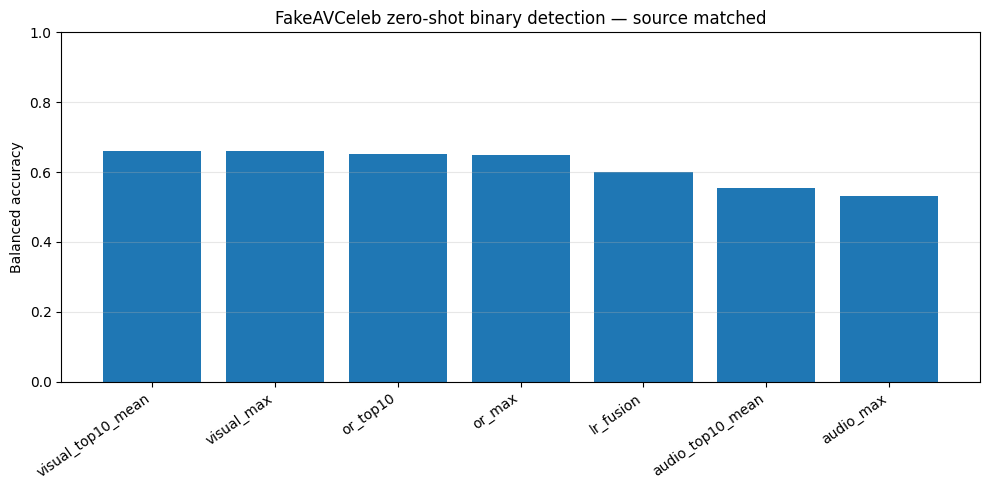

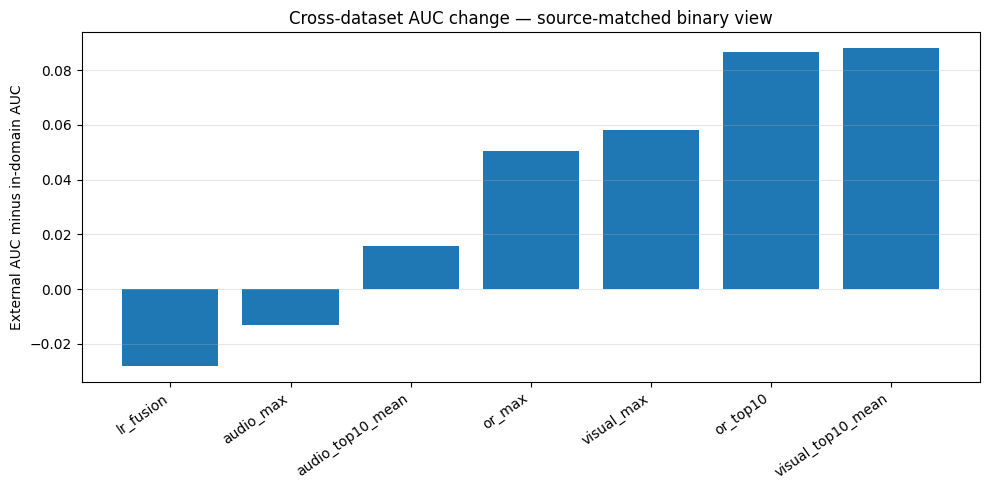

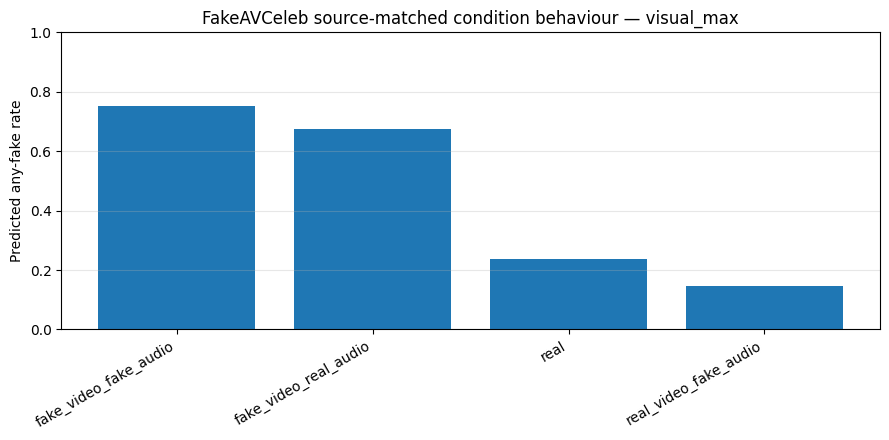

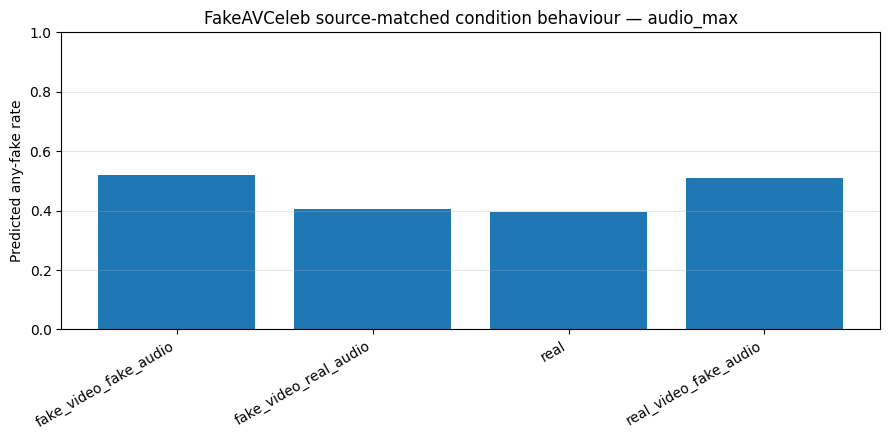

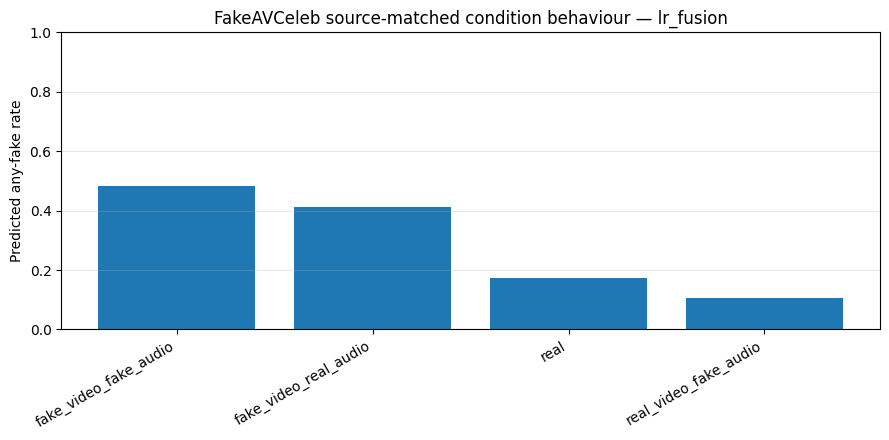

In [17]:
# final controlled-view / cross-dataset plots
primary_binary = external_metrics[
    (external_metrics["view"] == "source_matched_binary")
    & (external_metrics["task"] == "binary_any_fake")
].sort_values("balanced_accuracy", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(primary_binary["method"], primary_binary["balanced_accuracy"])
plt.ylabel("Balanced accuracy")
plt.title("FakeAVCeleb zero-shot binary detection — source matched")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    DIRS["plots"] / "fakeavceleb_source_matched_binary_balanced_accuracy.png",
    dpi=200,
)
plt.show()

controlled_change = performance_change[
    (performance_change["view"] == "source_matched_binary")
    & (performance_change["task"] == "binary_any_fake")
].sort_values("auc_change")

plt.figure(figsize=(10, 5))
plt.bar(controlled_change["method"], controlled_change["auc_change"])
plt.ylabel("External AUC minus in-domain AUC")
plt.title("Cross-dataset AUC change — source-matched binary view")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    DIRS["plots"] / "crossdataset_source_matched_auc_change.png",
    dpi=200,
)
plt.show()

for method in ["visual_max", "audio_max", "lr_fusion"]:
    group = condition_metrics[
        (condition_metrics["view"] == "source_matched4")
        & (condition_metrics["method"] == method)
    ]
    plt.figure(figsize=(9, 4.5))
    plt.bar(group["condition"], group["predicted_fake_rate"])
    plt.ylabel("Predicted any-fake rate")
    plt.title(f"FakeAVCeleb source-matched condition behaviour — {method}")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(DIRS["plots"] / f"source_matched_condition_{method}.png", dpi=200)
    plt.show()

In [18]:
# save the main results summary + old notebook snapshot helper
PRIMARY_BINARY_METHOD = "lr_fusion"
PRIMARY_VISUAL_METHOD = "visual_max"
PRIMARY_AUDIO_METHOD = "audio_max"

primary_binary_row = external_metrics[
    (external_metrics["view"] == "source_matched_binary")
    & (external_metrics["task"] == "binary_any_fake")
    & (external_metrics["method"] == PRIMARY_BINARY_METHOD)
].iloc[0]
primary_visual_row = external_metrics[
    (external_metrics["view"] == "source_matched4")
    & (external_metrics["task"] == "visual_specific")
    & (external_metrics["method"] == PRIMARY_VISUAL_METHOD)
].iloc[0]
primary_audio_row = external_metrics[
    (external_metrics["view"] == "source_matched4")
    & (external_metrics["task"] == "audio_specific")
    & (external_metrics["method"] == PRIMARY_AUDIO_METHOD)
].iloc[0]

summary = f"""# {RUN_NAME} results

## Dataset and validity

- Evaluation videos: {len(scores):,}
- Unique source identities represented: {scores['source'].nunique():,}
- Visual decode coverage: {scores['visual_decode_ok'].mean():.4f}
- Audio decode coverage: {scores['audio_decode_ok'].mean():.4f}
- Both-modality decode coverage: {scores['both_decode_ok'].mean():.4f}
- Ambiguous metadata method paths retained once: {int(scores['method_ambiguous'].sum()):,}

## Pre-specified controlled-view results

- Visual-specific `{PRIMARY_VISUAL_METHOD}` balanced accuracy: {primary_visual_row['balanced_accuracy']:.4f}
- Visual-specific `{PRIMARY_VISUAL_METHOD}` AUC: {primary_visual_row['auc']:.4f}
- Audio-specific `{PRIMARY_AUDIO_METHOD}` balanced accuracy: {primary_audio_row['balanced_accuracy']:.4f}
- Audio-specific `{PRIMARY_AUDIO_METHOD}` AUC: {primary_audio_row['auc']:.4f}
- Binary `{PRIMARY_BINARY_METHOD}` balanced accuracy: {primary_binary_row['balanced_accuracy']:.4f}
- Binary `{PRIMARY_BINARY_METHOD}` AUC: {primary_binary_row['auc']:.4f}

Thresholds were selected only from AV-Deepfake1M++ validation scores. The learned fusion model was fitted only on AV-Deepfake1M++ training predictions. FakeAVCeleb labels were not used for training, threshold selection, pooling selection or fusion fitting.
"""

(RUN_DIR / "results_summary.md").write_text(summary)
print(summary)


def snapshot_notebook():
    """copy the saved notebook file into the experiment snapshot folder."""
    if not NOTEBOOK_PATH.exists():
        raise FileNotFoundError(f"Save the notebook as {NOTEBOOK_PATH}")
    if NOTEBOOK_PATH.name != NOTEBOOK_FILENAME:
        raise ValueError("Unexpected notebook filename.")
    if NOTEBOOK_PATH.stat().st_size < 10 * 1024:
        raise ValueError("Notebook file is unexpectedly small; save it before snapshotting.")

    destination = (
        DIRS["notebook"]
        / f"final_snapshot_{datetime.now().strftime('%Y%m%d_%H%M%S')}.ipynb"
    )
    shutil.copy2(NOTEBOOK_PATH, destination)
    print("Snapshot:", destination)
    return destination


# this copies the notebook from the original qmul project path
snapshot_path = snapshot_notebook()

# exp008_fakeavceleb_crossdataset results

## Dataset and validity

- Evaluation videos: 21,544
- Unique source identities represented: 500
- Visual decode coverage: 1.0000
- Audio decode coverage: 1.0000
- Both-modality decode coverage: 1.0000
- Ambiguous metadata method paths retained once: 22

## Pre-specified controlled-view results

- Visual-specific `visual_max` balanced accuracy: 0.7655
- Visual-specific `visual_max` AUC: 0.8346
- Audio-specific `audio_max` balanced accuracy: 0.5225
- Audio-specific `audio_max` AUC: 0.5770
- Binary `lr_fusion` balanced accuracy: 0.6002
- Binary `lr_fusion` AUC: 0.6358

Thresholds were selected only from AV-Deepfake1M++ validation scores. The learned fusion model was fitted only on AV-Deepfake1M++ training predictions. FakeAVCeleb labels were not used for training, threshold selection, pooling selection or fusion fitting.



FileNotFoundError: Save the notebook as /home/jovyan/MSC_PROJECT/exp008_fakeavceleb_crossdataset.ipynb

In [19]:
# old helper used to make the smaller exp008 export zip
def zip_run():
    """zip the run outputs while leaving out the large resumable score shards."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_path = EXPORTS_DIR / f"{RUN_NAME}_{timestamp}.zip"

    with zipfile.ZipFile(output_path, "w", zipfile.ZIP_DEFLATED) as archive:
        for path in RUN_DIR.rglob("*"):
            if not path.is_file():
                continue
            if "score_shards" in path.parts:
                continue
            archive.write(path, Path(RUN_NAME) / path.relative_to(RUN_DIR))

    print("Created:", output_path)
    print("Size (MB):", output_path.stat().st_size / 1024**2)
    return output_path


# export the saved run files
zip_path = zip_run()
display(FileLink(str(zip_path)))

Created: /home/jovyan/MSC_PROJECT/exports/exp008_fakeavceleb_crossdataset_20260730_020056.zip
Size (MB): 8.648476600646973


/home/jovyan/MSC_PROJECT/exports/exp008_fakeavceleb_crossdataset_20260730_020056.zip

## result reminders

things i need to remember from exp008:

- this is **zero-shot cross-dataset** evaluation: FakeAVCeleb labels are not used for retraining, threshold selection, pooling selection or fusion fitting
- the full natural release is heavily fake-dominated, so accuracy/F1 there are less directly interpretable than in the balanced controlled binary view
- source-matched4 is for condition/modality comparison; source-matched binary is the cleanest binary comparison
- visual/audio scores come from the source exp004/exp005 temporal models, then are pooled to video level because FakeAVCeleb has no compatible temporal intervals
- all 21,544 unique physical videos are kept once in the full view; the 22 ambiguous duplicate metadata paths are not duplicated as separate videos
- codec/decode behaviour matters for the audio result and is recorded during scoring
- do not claim cross-dataset temporal IoU from this experiment because the target dataset does not provide compatible temporal labels